# Entraînement du modèle de segmentation pulmonaire (U-Net)

## U-Net

U-Net est une architecture de réseau de neurones convolutif (CNN) conçue en 2015 pour la segmentation d'images médicales, mais aujourd'hui utilisée pour toute segmentation sémantique. Son nom vient de sa forme en "U" quand on la dessine.

# Le principe

L'idée : produire, pour chaque pixel de l'image, une classe (ex: "poumon" vs "fond", ou "zone infectée" vs "saine"), pas juste une étiquette globale pour toute l'image.

# L'architecture en U

1. Le chemin de contraction (encoder) — bras gauche du U

Une succession de blocs Conv → Conv → ReLU → MaxPooling
À chaque étage, la résolution spatiale diminue (ex: 256×256 → 128×128 → 64×64...) mais le nombre de canaux (features) augmente
Le réseau apprend le "quoi" : des features de plus en plus abstraites (contours → textures → formes → structures)

2. Le goulot d'étranglement (bottleneck)

Le point le plus bas du U, où la représentation est la plus compressée/abstraite

3. Le chemin d'expansion (decoder) — bras droit du U

Des Upsampling (ou convolutions transposées) qui remontent progressivement la résolution
Le réseau réapprend le "où" : à quel endroit précis se trouve chaque structure

4. Les skip connections — la clé du U-Net

À chaque niveau, les features de l'encoder sont concaténées directement aux features correspondantes du decoder (les flèches horizontales du U)
Sans elles, le decoder ne récupérerait que l'information très compressée du bottleneck et perdrait les détails fins (bords précis, petites structures)
C'est ce qui permet une segmentation avec des contours nets, pixel par pixel
Pourquoi c'est efficace
L'encoder capture le contexte (qu'est-ce qu'on regarde globalement)
Le decoder + skip connections restaurent la localisation précise
Résultat : une carte de segmentation de même résolution que l'image d'entrée, avec une classe par pixel
Sortie finale
Une dernière convolution 1×1 ramène le nombre de canaux au nombre de classes (souvent suivie d'une sigmoid pour du binaire, ou softmax pour du multi-classe), donnant un masque de segmentation.


Ce notebook entraîne un U-Net (encoder MobileNetV2 pré-entraîné, decoder + skip connections codés à la main) à partir des couples (image, mask) du dataset COVID-19 Radiography.

Ce modèle sert à générer le mask des poumons pour les images reçues sur `predict/`, qui n'ont pas de mask associé (contrairement au dataset raw). Le mask prédit permet de reproduire à l'inférence le même preprocessing (masking + crop + CLAHE) que celui appliqué au training set du modèle de classification (voir `trainer/deep_learning/preprocessing.py`).

Version équivalente en pipeline DVC/MLflow : stages `preprocess_segmentation` / `train_segmentation` / `evaluate_segmentation` dans `dvc.yaml`, qui réutilisent l'architecture et les utilitaires de `trainer/deep_learning/segmentation.py` (paquet du service d'entraînement — pas du backend, qui appelle un segmentation-service séparé en HTTP à l'inférence). Ce notebook reste utile pour l'exploration rapide sur Colab GPU avec le dataset complet, en dehors du pipeline DVC.


In [1]:
import zipfile
from datetime import datetime
from pathlib import Path

import cv2
import keras
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from keras import layers
from sklearn.model_selection import train_test_split

print("GPU disponible:", tf.config.list_physical_devices("GPU"))


GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Config

CLASSES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]
IMG_SIZE = 256            # dataset complet + GPU sur Colab -> pas besoin de réduire comme en local CPU
BATCH_SIZE = 32
SEED = 42
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
SUBSET_FRACTION = 1.0     # 1.0 = dataset complet ; réduire pour un run rapide de vérification

# Entraînement en 2 phases (cf. build_unet) : l'encoder MobileNetV2 pré-entraîné ne doit
# pas être fine-tuné en entier dès le départ avec un LR élevé, sous peine de détruire les
# poids ImageNet (constaté en pratique : le val_dice s'effondre après 1-2 epochs si on
# dégèle tout dès le début avec LR=1e-3).
FREEZE_EPOCHS = 8         # phase 1 : encoder gelé, seul le decoder apprend, LR normal
FINE_TUNE_EPOCHS = 25     # phase 2 : encoder dégelé, LR très bas pour affiner sans casser
FINE_TUNE_BATCH_SIZE = BATCH_SIZE // 2  # phase 2 plus gourmande en mémoire GPU (gradients sur tout le réseau)


In [3]:
from google.colab import drive

drive.mount('/content/drive')

RAW_ZIP_PATH = Path("/content/drive/MyDrive/DS_COVID/archive_dataset.zip")

RAW_EXTRACT_DIR = Path("/content/data/raw")

with zipfile.ZipFile(RAW_ZIP_PATH) as zf:
    zf.extractall(RAW_EXTRACT_DIR)

# We check if the dataset has been extracted correctly by looking for the expected classes
# in the extracted directory and we count the number of images/masks in each class directory.

for class_name in CLASSES:
    class_dir = RAW_EXTRACT_DIR / "COVID-19_Radiography_Dataset" / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Expected class directory '{class_dir}' not found. Please check the dataset extraction.")
    else:
        print(f"Found class directory: {class_dir}")

    img_dir = class_dir / "images"
    mask_dir = class_dir / "masks"

    # Count the number of images (PNG) in the class directory
    num_images = len(list(img_dir.glob("*.png")))
    print(f"Number of images in {class_name}: {num_images}")

    # Count the number of masks (PNG) in the class directory
    num_masks = len(list(mask_dir.glob("*.png")))
    print(f"Number of masks in {class_name}: {num_masks}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found class directory: /content/data/raw/COVID-19_Radiography_Dataset/COVID
Number of images in COVID: 3616
Number of masks in COVID: 3616
Found class directory: /content/data/raw/COVID-19_Radiography_Dataset/Normal
Number of images in Normal: 10192
Number of masks in Normal: 10192
Found class directory: /content/data/raw/COVID-19_Radiography_Dataset/Lung_Opacity
Number of images in Lung_Opacity: 6012
Number of masks in Lung_Opacity: 6012
Found class directory: /content/data/raw/COVID-19_Radiography_Dataset/Viral Pneumonia
Number of images in Viral Pneumonia: 1345
Number of masks in Viral Pneumonia: 1345


In [4]:

MODELS_DIR = Path("/content/drive/MyDrive/DS_COVID/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Construction du pipeline `tf.data` (image, mask)

In [5]:
def collect_pairs(source_path: Path):
    """Liste tous les couples (image, mask) disponibles, toutes classes confondues, avec le
    label de classe associé (utilisé uniquement pour stratifier le split train/val/test :
    la tâche de segmentation elle-même - silhouette des poumons - est indépendante du label
    pathologique de l'image).

    Returns:
        (img_paths, mask_paths, class_labels) - 3 np.ndarray de même longueur
    """
    img_paths, mask_paths, class_labels = [], [], []
    for class_idx, class_name in enumerate(CLASSES):
        images_dir = source_path / class_name / "images"
        masks_dir = source_path / class_name / "masks"
        for img_path in sorted(images_dir.glob("*.png")):
            mask_path = masks_dir / img_path.name
            if mask_path.exists():
                img_paths.append(str(img_path))
                mask_paths.append(str(mask_path))
                class_labels.append(class_idx)
    return np.array(img_paths), np.array(mask_paths), np.array(class_labels)


def load_pair(img_path: tf.Tensor, mask_path: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels=1)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest")  # nearest : garde le mask binaire
    mask = tf.cast(mask > 127, tf.float32)

    return img, mask


def build_dataset(img_paths, mask_paths, shuffle: bool) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices((list(img_paths), list(mask_paths)))
    if shuffle:
        ds = ds.shuffle(len(img_paths), seed=SEED)
    ds = ds.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


img_paths, mask_paths, class_labels = collect_pairs(RAW_EXTRACT_DIR / "COVID-19_Radiography_Dataset")
print(f"Paires image/mask trouvées: {len(img_paths)}")

if SUBSET_FRACTION < 1.0:
    rng = np.random.default_rng(SEED)
    n_subset = int(len(img_paths) * SUBSET_FRACTION)
    idx = rng.choice(len(img_paths), size=n_subset, replace=False)
    img_paths, mask_paths, class_labels = img_paths[idx], mask_paths[idx], class_labels[idx]
    print(f"Run rapide sur un sous-échantillon: {len(img_paths)} paires")

# Split stratifié par classe pathologique : train / (val+test), puis val / test
img_train, img_temp, mask_train, mask_temp, cls_train, cls_temp = train_test_split(
    img_paths, mask_paths, class_labels,
    test_size=VAL_FRACTION + TEST_FRACTION,
    stratify=class_labels,
    random_state=SEED,
)
img_val, img_test, mask_val, mask_test, cls_val, cls_test = train_test_split(
    img_temp, mask_temp, cls_temp,
    test_size=TEST_FRACTION / (VAL_FRACTION + TEST_FRACTION),
    stratify=cls_temp,
    random_state=SEED,
)

print(f"Train: {len(img_train)}  Val: {len(img_val)}  Test: {len(img_test)}")

train_ds = build_dataset(img_train, mask_train, shuffle=True)
val_ds = build_dataset(img_val, mask_val, shuffle=False)
test_ds = build_dataset(img_test, mask_test, shuffle=False)


Paires image/mask trouvées: 21165
Train: 14815  Val: 3175  Test: 3175


## 2. Sanity check visuel

Batch images: (32, 256, 256, 1) <dtype: 'float32'> min/max: 0.0 1.0
Batch masks: (32, 256, 256, 1) <dtype: 'float32'> valeurs uniques: [0. 1.]


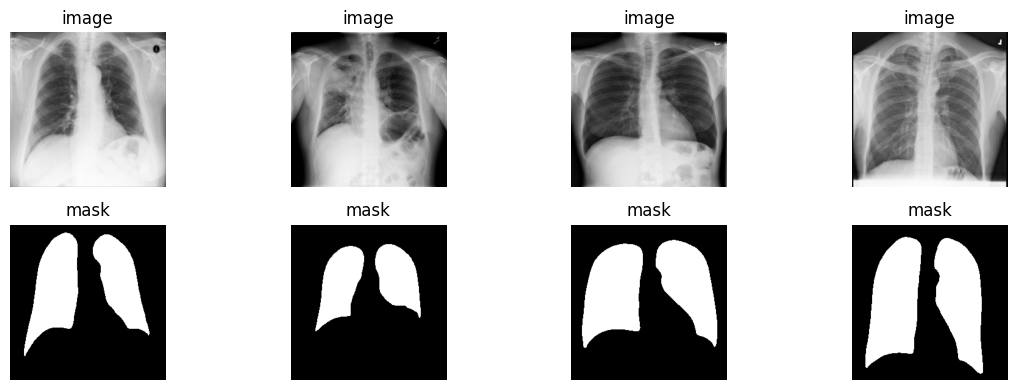

In [6]:
for imgs, masks in train_ds.take(1):
    print("Batch images:", imgs.shape, imgs.dtype, "min/max:", float(tf.reduce_min(imgs)), float(tf.reduce_max(imgs)))
    print("Batch masks:", masks.shape, masks.dtype, "valeurs uniques:", np.unique(masks.numpy()))

    plt.figure(figsize=(12, 4))
    for i in range(min(4, imgs.shape[0])):
        plt.subplot(2, 4, i + 1)
        plt.imshow(imgs[i, :, :, 0], cmap="gray")
        plt.title("image")
        plt.axis("off")

        plt.subplot(2, 4, i + 5)
        plt.imshow(masks[i, :, :, 0], cmap="gray")
        plt.title("mask")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


## 3. U-Net (encoder MobileNetV2 pré-entraîné)

In [7]:
def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1)) -> tuple[keras.Model, keras.Model]:
    """U-Net avec encoder MobileNetV2 pré-entraîné (ImageNet) et decoder + skip connections codés à la main.

    Renvoie (model, encoder) : `encoder` est nécessaire pour geler/dégeler ses layers
    entre la phase 1 (decoder seul) et la phase 2 (fine-tuning complet). Les layers de
    `encoder` sont les mêmes instances que celles utilisées dans le graphe de `model|
    (extraites par tenseurs de sortie, pas appelées comme sous-modèle) : changer leur
    `.trainable` affecte donc directement l'entraînement de `model`.
    """
    inputs = keras.Input(shape=input_shape)

    # MobileNetV2 attend 3 canaux -> on duplique le canal grayscale
    x = layers.Concatenate()([inputs, inputs, inputs])

    encoder = keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights="imagenet")

    skip_names = ["block_1_expand_relu", "block_3_expand_relu", "block_6_expand_relu", "block_13_expand_relu"]
    skips = [encoder.get_layer(n).output for n in skip_names]
    bottleneck = encoder.get_layer("block_16_project").output

    x = bottleneck
    for skip in reversed(skips):
        x = layers.Conv2DTranspose(skip.shape[-1], 3, strides=2, padding="same")(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(skip.shape[-1], 3, padding="same", activation="relu")(x)
        x = layers.Conv2D(skip.shape[-1], 3, padding="same", activation="relu")(x)

    outputs = layers.Conv2DTranspose(1, 3, strides=2, padding="same", activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="lung_unet")
    return model, encoder


def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = keras.ops.reshape(y_true, [-1])
    y_pred_f = keras.ops.reshape(y_pred, [-1])
    intersection = keras.ops.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (keras.ops.sum(y_true_f) + keras.ops.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)


def combined_loss(y_true, y_pred):
    return keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, smooth=1.0):
    y_true_f = keras.ops.reshape(y_true, [-1])
    y_pred_f = keras.ops.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    intersection = keras.ops.sum(y_true_f * y_pred_f)
    union = keras.ops.sum(y_true_f) + keras.ops.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


model, encoder = build_unet()
model.summary()


/tmp/ipykernel_17071/1156555735.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  encoder = keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights="imagenet")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "lung_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 3)                │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 15,635,313 (59.64 MB)

 Trainable params: 15,604,401 (59.53 MB)

 Non-trainable params: 30,912 (120.75 KB)

## 4. Entraînement

In [8]:
run_name = f"unet_seg_{datetime.now().strftime('%Y%m%d-%H%M%S')}"

# --- Phase 1 : encoder gelé, seul le decoder (initialisé aléatoirement) apprend ---
for layer in encoder.layers:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=combined_loss, metrics=[dice_coef, iou_metric])
print(f"--- Phase 1/2 : decoder seul (encoder gelé), LR=1e-3, jusqu'à {FREEZE_EPOCHS} epochs ---")

history_freeze = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FREEZE_EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        # Le decoder seul (encoder gelé) peut quand même déstabiliser à LR constant une fois
        # qu'il a bien convergé (observé en pratique : chute brutale après ~6 epochs à 1e-3) ;
        # ce ReduceLROnPlateau baisse le LR avant que ça arrive.
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5),
    ],
)

# --- Phase 2 : encoder dégelé, fine-tuning complet avec un LR beaucoup plus bas ---
# LR 100x plus faible qu'en phase 1 : l'objectif est d'affiner les features ImageNet à la
# marge, pas de les réapprendre (un LR aussi haut qu'en phase 1 les détruirait, cf.
# l'effondrement du val_dice observé en fine-tunant tout d'un coup à 1e-3).
for layer in encoder.layers:
    layer.trainable = True

model.compile(optimizer=keras.optimizers.Adam(1e-5), loss=combined_loss, metrics=[dice_coef, iou_metric])
print(f"--- Phase 2/2 : fine-tuning complet (encoder dégelé), LR=1e-5, jusqu'à {FINE_TUNE_EPOCHS} epochs ---")

# Fine-tuner tout l'encoder demande de stocker les gradients/activations de tout le réseau
# (pas juste du decoder comme en phase 1) : ça peut faire déborder la mémoire GPU au même
# batch size que la phase 1 (OOM observé en pratique). On rebatch à la volée avec une taille
# plus petite, sans toucher à train_ds/val_ds pour un éventuel futur run en phase 1 seule.
train_ds_ft = train_ds.unbatch().batch(FINE_TUNE_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds_ft = val_ds.unbatch().batch(FINE_TUNE_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint(
        MODELS_DIR / f"{run_name}_best.keras", monitor="val_loss", save_best_only=True
    ),
]

history_finetune = model.fit(train_ds_ft, validation_data=val_ds_ft, epochs=FINE_TUNE_EPOCHS, callbacks=callbacks)


--- Phase 1/2 : decoder seul (encoder gelé), LR=1e-3, jusqu'à 8 epochs ---
Epoch 1/8
448/463 ━━━━━━━━━━━━━━━━━━━━ 6s 444ms/step - dice_coef: 0.7019 - iou_metric: 0.6165 - loss: 0.5679

KeyboardInterrupt: 

In [ ]:
def concat_history(key):
    return history_freeze.history.get(key, []) + history_finetune.history.get(key, [])


split_epoch = len(history_freeze.history["loss"])  # frontière phase 1 -> phase 2, pour repère visuel

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ["loss", "dice_coef", "iou_metric"], ["Loss", "Dice", "IoU"], strict=True):
    ax.plot(concat_history(key), label="train")
    ax.plot(concat_history(f"val_{key}"), label="val")
    ax.axvline(split_epoch - 0.5, color="gray", linestyle="--", linewidth=1, label="fin phase 1")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()


## 5. Évaluation sur le jeu de test

In [ ]:
test_loss, test_dice, test_iou = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}  Dice: {test_dice:.4f}  IoU: {test_iou:.4f}")


### Post-traitement : nettoyage du mask prédit

Le mask brut (seuillage à 0.5) contient parfois des îlots isolés ou de petits trous. On les corrige avant tout usage en aval (masking, crop).

In [ ]:
# Post-traitement du mask prédit : élimine les îlots parasites et comble les petits trous.
# Duplique clean_mask() de trainer/deep_learning/segmentation.py (notebook autonome sur
# Colab, pas d'import du repo) - gardez les deux en synchro si vous modifiez l'un des deux.
# Le segmentation-service (backend, à l'inférence) a sa propre copie indépendante
# (segmentation-service/src/segmentation_service/model.py), pas celle-ci.
def clean_mask(mask, n_components=2, closing_kernel_size=15):
    mask_binary = (mask > 0).astype(np.uint8) * 255

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_binary, connectivity=8)
    if n_labels <= 1:
        return mask_binary

    areas = stats[1:, cv2.CC_STAT_AREA]
    n_keep = min(n_components, len(areas))
    keep_labels = np.argsort(areas)[::-1][:n_keep] + 1

    cleaned = np.isin(labels, keep_labels).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (closing_kernel_size, closing_kernel_size))
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

    return cleaned


In [ ]:
# Visualisation : image | mask réel | mask prédit (brut) | mask prédit (nettoyé)
for imgs, masks in test_ds.take(1):
    preds = model.predict(imgs, verbose=0)

    plt.figure(figsize=(12, 8))
    for i in range(min(4, imgs.shape[0])):
        pred_raw = (preds[i, :, :, 0] > 0.5).astype(np.uint8)
        pred_clean = clean_mask(pred_raw)

        plt.subplot(4, 4, i + 1)
        plt.imshow(imgs[i, :, :, 0], cmap="gray")
        plt.title("image")
        plt.axis("off")

        plt.subplot(4, 4, i + 5)
        plt.imshow(masks[i, :, :, 0], cmap="gray")
        plt.title("mask réel")
        plt.axis("off")

        plt.subplot(4, 4, i + 9)
        plt.imshow(pred_raw, cmap="gray")
        plt.title("mask prédit (brut)")
        plt.axis("off")

        plt.subplot(4, 4, i + 13)
        plt.imshow(pred_clean, cmap="gray")
        plt.title("mask prédit (nettoyé)")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


### Vue d'ensemble sur un plus grand échantillon

Même logique que ci-dessus, mais sur 50 exemples du test set pour repérer d'éventuels cas problématiques au-delà des 4 exemples détaillés. Contours superposés plutôt que masks séparés, pour rester lisible à cette échelle.

In [ ]:
N_SAMPLES = 50
N_COLS = 10

imgs_sample, masks_sample, preds_sample = [], [], []
for imgs, masks in test_ds:
    preds = model.predict(imgs, verbose=0)
    for i in range(imgs.shape[0]):
        imgs_sample.append(imgs[i, :, :, 0].numpy())
        masks_sample.append(masks[i, :, :, 0].numpy())
        pred_raw = (preds[i, :, :, 0] > 0.5).astype(np.uint8)
        preds_sample.append(clean_mask(pred_raw))
        if len(imgs_sample) >= N_SAMPLES:
            break
    if len(imgs_sample) >= N_SAMPLES:
        break

n_rows = int(np.ceil(len(imgs_sample) / N_COLS))
plt.figure(figsize=(N_COLS * 2, n_rows * 2))
for idx in range(len(imgs_sample)):
    plt.subplot(n_rows, N_COLS, idx + 1)
    plt.imshow(imgs_sample[idx], cmap="gray")
    plt.contour(masks_sample[idx], colors="red", linewidths=0.8)       # mask réel
    plt.contour(preds_sample[idx] > 0, colors="lime", linewidths=0.8)  # mask prédit (nettoyé)
    plt.axis("off")

plt.suptitle(f"Rouge = mask réel, Vert = mask prédit nettoyé ({len(imgs_sample)} exemples du test set)")
plt.tight_layout()
plt.show()


## 6. Sauvegarde du modèle final

⚠️ Sur Colab, `MODELS_DIR` pointe vers le runtime éphémère (`/content/models`) : le modèle sera perdu à la déconnexion. Copie-le sur Drive si tu veux le garder (dernière cellule).

In [ ]:
final_path = MODELS_DIR / f"{run_name}_final.keras"
model.save(final_path)
print(f"Modèle sauvegardé dans: {final_path}")
